<a href="https://colab.research.google.com/github/LucasBrbs/CG/blob/main/CG.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Trabalho CG
Equipe: Adriano Santos de Oliveira Junior e Lucas Barbosa de Oliveira

## 1. Modelando Objetos

### Cubo

In [ ]:
# CUBO SIMPLES COM MARCHING CUBES - GOOGLE COLAB
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
from skimage.measure import marching_cubes

class Cubo:
    def __init__(self, tamanho_aresta):
        self.tamanho = tamanho_aresta
        self.vertices = self._calcular_vertices()
        self.arestas = self._definir_arestas()

    def _calcular_vertices(self):
        t = self.tamanho
        vertices = [
            [0, 0, 0], [t, 0, 0], [t, t, 0], [0, t, 0],  # base inferior
            [0, 0, t], [t, 0, t], [t, t, t], [0, t, t]   # base superior
        ]
        return vertices

    def _definir_arestas(self):
        arestas = [
            (0, 1), (1, 2), (2, 3), (3, 0),  # base inferior
            (4, 5), (5, 6), (6, 7), (7, 4),  # base superior
            (0, 4), (1, 5), (2, 6), (3, 7)   # verticais
        ]
        return arestas

    def gerar_campo_escalar(self, resolucao=32):
        # Aumentamos o limite da grade um pouco para o Marching Cubes não cortar as faces
        margem_grade = self.tamanho * 0.2
        x = np.linspace(-margem_grade, self.tamanho + margem_grade, resolucao)
        y = np.linspace(-margem_grade, self.tamanho + margem_grade, resolucao)
        z = np.linspace(-margem_grade, self.tamanho + margem_grade, resolucao)
        X, Y, Z = np.meshgrid(x, y, z, indexing='ij')

        # Cubo perfeito: positivo dentro, negativo fora.
        # O nível 0 será exatamente em 0 e self.tamanho
        campo = np.minimum.reduce([
            X, self.tamanho - X,
            Y, self.tamanho - Y,
            Z, self.tamanho - Z
        ])

        # Guardamos o passo da grade para o spacing correto
        self.grid_step = x[1] - x[0]
        self.grid_min = -margem_grade

        return campo

    def gerar_marching_cubes(self, resolucao=32):
        """Gera cubo com Marching Cubes e plota resultado"""
        print(f"Gerando Marching Cubes (resolução {resolucao})...")

        # 1. Criar campo escalar (usando a nova lógica de grade com margem externa)
        campo = self.gerar_campo_escalar(resolucao)

        # 2. Aplicar Marching Cubes
        # IMPORTANTE: Usamos o self.grid_step calculado no gerar_campo_escalar
        # para que 1 unidade na grade equivalha a 1 unidade no espaço 3D.
        vertices, faces, normals, _ = marching_cubes(
            campo,
            level=0.0,
            spacing=(self.grid_step, self.grid_step, self.grid_step)
        )

        # 3. Ajuste de Posição (Offset)
        # Como a grade começou em -margem_grade (self.grid_min),
        # precisamos compensar esse deslocamento nos vértices.
        vertices += self.grid_min

        print(f"✓ Gerado: {len(vertices)} vértices, {len(faces)} faces")
        print(f"Extensões reais: X:[{vertices[:,0].min():.2f}, {vertices[:,0].max():.2f}]")

        # 4. Plotar resultado
        self.plotar_cubo_marching(vertices, faces)

        return {'vertices': vertices, 'faces': faces, 'normals': normals}

    def plotar_cubo_marching(self, vertices, faces):
        """Plota o cubo gerado pelo Marching Cubes"""
        fig = plt.figure(figsize=(10, 8))
        ax = fig.add_subplot(111, projection='3d')

        # Criar coleção de triângulos
        triangulos = []
        for face in faces:
            triangulo = [vertices[face[0]], vertices[face[1]], vertices[face[2]]]
            triangulos.append(triangulo)

        # Adicionar superfície 3D
        mesh_collection = Poly3DCollection(triangulos, alpha=0.7,
                                         facecolor='lightblue',
                                         edgecolor='navy',
                                         linewidth=0.5)
        ax.add_collection3d(mesh_collection)

        # Configurar visualização
        ax.set_title(f'Cubo Marching Cubes (aresta={self.tamanho})', fontsize=14)
        ax.set_xlabel('X')
        ax.set_ylabel('Y')
        ax.set_zlabel('Z')

        # Ajustar limites
        ax.set_xlim(0, self.tamanho)
        ax.set_ylim(0, self.tamanho)
        ax.set_zlim(0, self.tamanho)

        plt.tight_layout()
        plt.show()

Gerando Marching Cubes (resolução 32)...
✓ Gerado: 2904 vértices, 5804 faces
Extensões reais: X:[-0.00, 2.00]


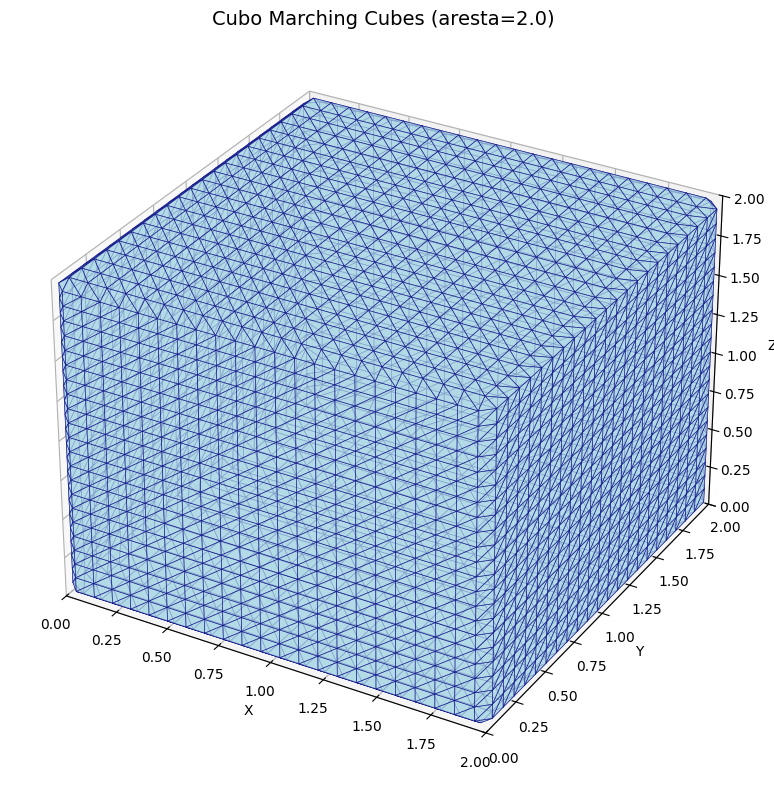

In [ ]:
# EXEMPLO SIMPLES PARA GOOGLE COLAB
if __name__ == "__main__":

    # 1. Criar e mostrar cubo
    cubo = Cubo(tamanho_aresta=2.0)

    # 2. Gerar e plotar com Marching Cubes
    mesh = cubo.gerar_marching_cubes(resolucao=32)


### Cano Curvado - Bezier

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# =====================================================
# 1) Funções auxiliares
# =====================================================

def bezier_cubica(t, P0, P1, P2, P3):
    return (1-t)**3 * P0 + \
           3*(1-t)**2 * t * P1 + \
           3*(1-t) * t**2 * P2 + \
           t**3 * P3

def get_frame(tangente):
    norm = np.linalg.norm(tangente) + 1e-8
    T = tangente / norm
    up = np.array([0, 0, 1])
    if abs(np.dot(up, T)) > 0.99:
        up = np.array([0, 1, 0])
    N = np.cross(T, up)
    N /= np.linalg.norm(N)
    B = np.cross(T, N)
    return N, B

# =====================================================
# 2) CLASSE DO CANO (COM TAMPAS E MATPLOTLIB CYAN)
# =====================================================

class CanoBezierOco:
    def __init__(self, P0, P1, P2, P3, r_ext, r_int, passos=30, fatias=15):
        self.P0 = np.array(P0)
        self.P1 = np.array(P1)
        self.P2 = np.array(P2)
        self.P3 = np.array(P3)
        self.r_ext = r_ext
        self.r_int = r_int
        self.passos = passos
        self.fatias = fatias
        self.vertices = None
        self.faces = None

    def gerar(self):
        vertices = []
        faces = []
        aneis = []

        # 1) Gerar Vértices (Externos e Internos)
        for i in range(self.passos + 1):
            t = i / self.passos
            centro = bezier_cubica(t, self.P0, self.P1, self.P2, self.P3)

            # Cálculo da tangente para o frame
            if t < 1:
                prox = bezier_cubica(t + 0.01, self.P0, self.P1, self.P2, self.P3)
                tang = prox - centro
            else:
                ant = bezier_cubica(t - 0.01, self.P0, self.P1, self.P2, self.P3)
                tang = centro - ant

            N, B = get_frame(tang)

            i_ext = []
            i_int = []

            for j in range(self.fatias):
                ang = 2*np.pi * j / self.fatias
                radial = np.cos(ang)*N + np.sin(ang)*B

                # Vértice Externo
                p_ext = centro + self.r_ext * radial
                vertices.append(p_ext)
                i_ext.append(len(vertices)-1)

                # Vértice Interno
                p_int = centro + self.r_int * radial
                vertices.append(p_int)
                i_int.append(len(vertices)-1)

            aneis.append({"ext": i_ext, "int": i_int})

        vertices = np.array(vertices)

        # Função auxiliar para criar triângulos a partir de 4 pontos
        def quad(a, b, c, d):
            faces.append([a, b, c])
            faces.append([a, c, d])

        # 2) Paredes Laterais
        for i in range(self.passos):
            for j in range(self.fatias):
                j2 = (j+1) % self.fatias

                # Índices do anel atual (i) e próximo (i+1)
                e0, e1 = aneis[i]["ext"][j], aneis[i]["ext"][j2]
                e2, e3 = aneis[i+1]["ext"][j2], aneis[i+1]["ext"][j]

                i0, i1 = aneis[i]["int"][j], aneis[i]["int"][j2]
                i2, i3 = aneis[i+1]["int"][j2], aneis[i+1]["int"][j]

                quad(e0, e1, e2, e3) # Parede Externa
                quad(i0, i3, i2, i1) # Parede Interna

        # 3) TAMPAS (O INÍCIO E O FIM)
        for idx in [0, self.passos]:
            anel = aneis[idx]
            for j in range(self.fatias):
                j2 = (j+1) % self.fatias

                e0 = anel["ext"][j]
                e1 = anel["ext"][j2]
                i1 = anel["int"][j2]
                i0 = anel["int"][j]

                # Inverte a ordem dependendo se é o começo ou o fim para a normal ficar correta
                if idx == 0:
                    quad(e0, i0, i1, e1)
                else:
                    quad(e0, e1, i1, i0)

        self.vertices = vertices
        self.faces = np.array(faces)

        # Retorna vertices e faces (o que o Matplotlib precisa)
        return self.vertices, self.faces

    def plotar(self):
        if self.vertices is None:
            self.gerar()

        v = self.vertices
        f = self.faces

        # Configuração Matplotlib
        fig = plt.figure(figsize=(8, 6))
        ax = fig.add_subplot(111, projection='3d')

        # --- MUDANÇA AQUI ---
        # Substituímos cmap='cool' por color='cyan'
        ax.plot_trisurf(v[:,0], v[:,1], v[:,2], triangles=f,
                        color='cyan', edgecolor='black', linewidth=0.2, alpha=0.9)
        # --------------------

        # Ajuste de escala para não distorcer (Aspect Ratio 1:1:1)
        max_range = np.array([v[:,0].max()-v[:,0].min(),
                              v[:,1].max()-v[:,1].min(),
                              v[:,2].max()-v[:,2].min()]).max() / 2.0
        mid_x = (v[:,0].max()+v[:,0].min()) * 0.5
        mid_y = (v[:,1].max()+v[:,1].min()) * 0.5
        mid_z = (v[:,2].max()+v[:,2].min()) * 0.5

        ax.set_xlim(mid_x - max_range, mid_x + max_range)
        ax.set_ylim(mid_y - max_range, mid_y + max_range)
        ax.set_zlim(mid_z - max_range, mid_z + max_range)

        ax.set_title("Cano Bézier com Tampas (Matplotlib Cyan)")
        plt.show()

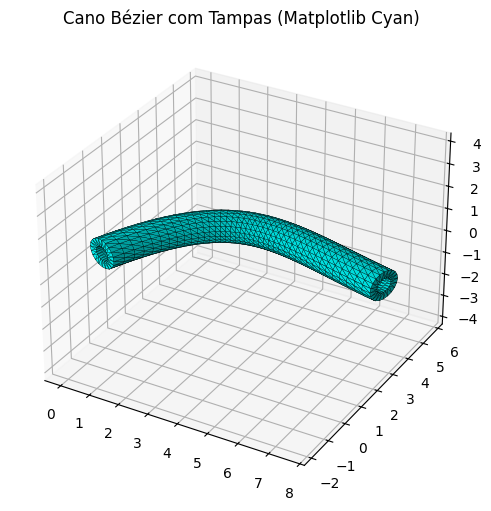

In [ ]:
# =====================================================
# TESTE
# =====================================================
if __name__ == "__main__":
    P0 = [0, 0, 0]
    P1 = [2, 5, 0]
    P2 = [4, 3.5, 0]
    P3 = [8, 2.5, 0]

    # Passos e fatias definem a resolução
    cano = CanoBezierOco(P0, P1, P2, P3, r_ext=0.6, r_int=0.3, passos=40, fatias=20)
    cano.plotar()

### Toro

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
from skimage.measure import marching_cubes

class Toro:
    def __init__(self, R, r):
        self.R = R   # Raio maior
        self.r = r   # Raio menor (do tubo)

    def gerar_campo_escalar(self, resolucao=64):
        """
        Gera o campo escalar otimizado para o tamanho do toro.
        """
        # Margem de 20% para garantir que o Marching Cubes feche o sólido
        margem = 1.2
        limite_xy = (self.R + self.r) * margem
        limite_z = self.r * margem

        # Criamos a grade. Note que o Z pode ter menos resolução se for muito fino,
        # mas manteremos proporcional para evitar distorção.
        x = np.linspace(-limite_xy, limite_xy, resolucao)
        y = np.linspace(-limite_xy, limite_xy, resolucao)
        z = np.linspace(-limite_z, limite_z, int(resolucao * (limite_z/limite_xy)) + 2)

        X, Y, Z = np.meshgrid(x, y, z, indexing='ij')

        # Equação implícita do toro
        campo = (np.sqrt(X**2 + Y**2) - self.R)**2 + Z**2 - self.r**2

        # Armazenamos informações para reconstrução dos vértices
        info_grade = {
            'step': (x[1]-x[0], y[1]-y[0], z[1]-z[0]),
            'min': (x[0], y[0], z[0]),
            'limite_xy': limite_xy
        }

        return campo, info_grade

    def gerar_marching_cubes(self, resolucao=64):
        """
        Gera o toro usando Marching Cubes com melhorias de performance.
        """
        print(f"Gerando Toro (R={self.R}, r={self.r})...")

        campo, info = self.gerar_campo_escalar(resolucao)

        # 1. Usamos 'spacing' para o algoritmo já devolver os vértices na escala correta
        vertices, faces, normals, _ = marching_cubes(
            campo,
            level=0.0,
            spacing=info['step']
        )

        # 2. Ajustamos a origem (offset) baseada no início da grade
        vertices[:, 0] += info['min'][0]
        vertices[:, 1] += info['min'][1]
        vertices[:, 2] += info['min'][2]

        print(f"✓ Toro gerado: {len(vertices)} vértices, {len(faces)} faces")

        # Mostra a malha passando o limite calculado
        self.plotar_toro_marching(vertices, faces, info['limite_xy'])

        return vertices, faces, normals

    def plotar_toro_marching(self, vertices, faces, limite):
        """
        Plota a malha de forma eficiente.
        """
        fig = plt.figure(figsize=(10, 8))
        ax = fig.add_subplot(111, projection='3d')

        # MELHORIA: Em vez de loop 'for', passamos vertices[faces] diretamente.
        # Isso é ordens de magnitude mais rápido para malhas densas.
        mesh = Poly3DCollection(
            vertices[faces],
            alpha=0.7,
            facecolor='orange',
            edgecolor='black',
            linewidth=0.1
        )
        ax.add_collection3d(mesh)

        ax.set_title(f"Toro Marching Cubes (R={self.R}, r={self.r})")
        ax.set_xlabel("X")
        ax.set_ylabel("Y")
        ax.set_zlabel("Z")

        # Ajusta os limites para focar no objeto
        ax.set_xlim(-limite, limite)
        ax.set_ylim(-limite, limite)
        ax.set_zlim(-limite, limite)

        # Mantém a proporção dos eixos igual para não achatar o toro
        ax.set_box_aspect([1,1,1])

        plt.show()

Gerando Toro (R=3.0, r=1.0)...
✓ Toro gerado: 7648 vértices, 15296 faces


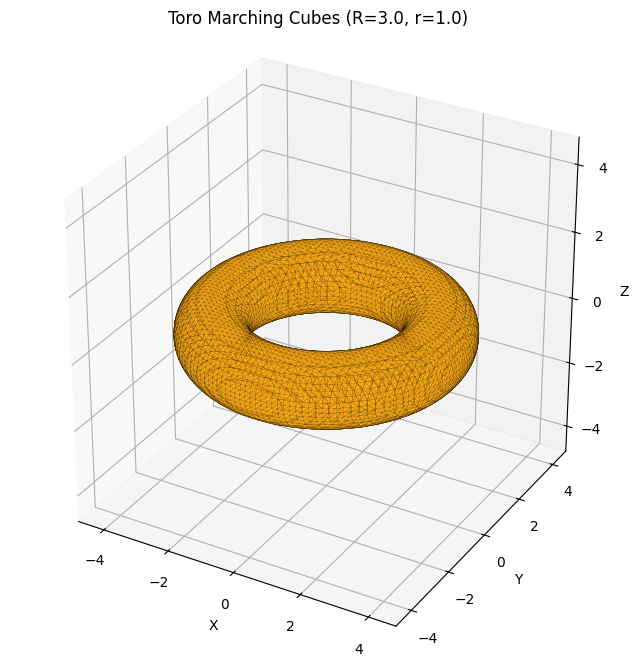

In [ ]:
if __name__ == "__main__":
    # Cria um toro (R = raio maior, r = raio menor)
    toro = Toro(R=3.0, r=1.0)
    # Gera e plota a malha com resolução mais densa
    toro.gerar_marching_cubes(resolucao=64)

## 2. Compor a Cena

### Funções de Transformação

In [ ]:
import numpy as np
import plotly.graph_objects as go

# ==========================================================
# 1. FUNÇÕES AUXILIARES DE TRANSFORMAÇÃO
# ==========================================================

def criar_matriz_rotacao(eixo, angulo_graus):
    """Retorna matriz de rotação 3x3 para X, Y ou Z."""
    rad = np.radians(angulo_graus)
    c, s = np.cos(rad), np.sin(rad)

    if eixo == 'x':
        return np.array([[1, 0, 0], [0, c, -s], [0, s, c]])
    elif eixo == 'y':
        return np.array([[c, 0, s], [0, 1, 0], [-s, 0, c]])
    elif eixo == 'z':
        return np.array([[c, -s, 0], [s, c, 0], [0, 0, 1]])
    return np.eye(3)

def aplicar_transformacao(vertices, escala=(1,1,1), rotacao_eixo=None, rotacao_ang=0, translacao=(0,0,0)):
    """
    Aplica Escala -> Rotação -> Translação nos vértices.
    vertices: Array (N, 3)
    """
    # 1. Escala
    v_transf = vertices * np.array(escala)

    # 2. Rotação
    if rotacao_eixo:
        matriz_rot = criar_matriz_rotacao(rotacao_eixo, rotacao_ang)
        # Transposta para multiplicar corretamente array (N,3)
        v_transf = np.dot(v_transf, matriz_rot.T)

    # 3. Translação
    v_transf = v_transf + np.array(translacao)

    return v_transf

### Montagem da Cena

Gerando objetos...
Gerando Marching Cubes (resolução 32)...
✓ Gerado: 2904 vértices, 5804 faces
Extensões reais: X:[-0.00, 2.00]


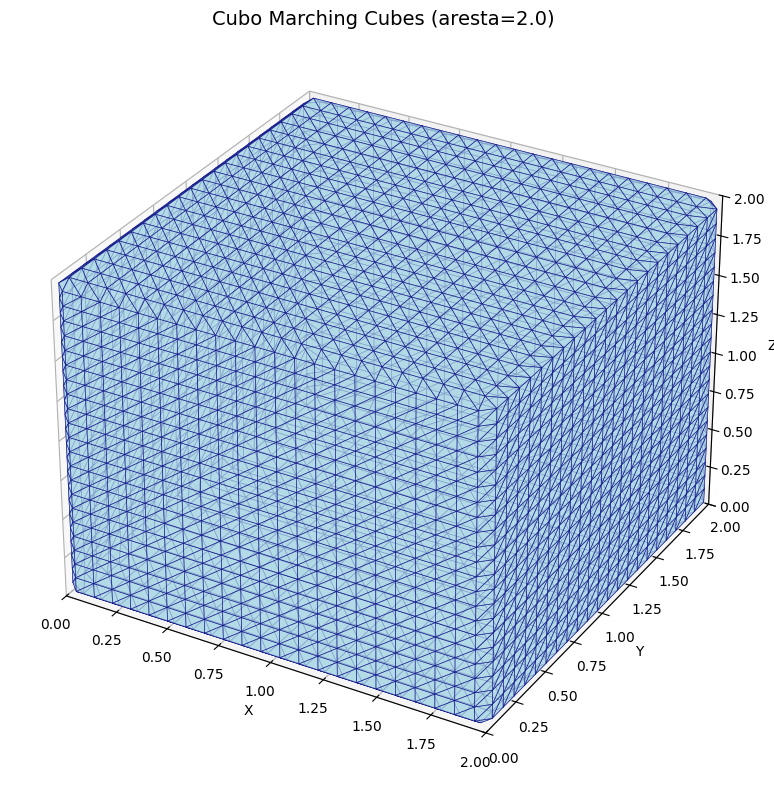

Gerando Toro (R=2.0, r=0.5)...
✓ Toro gerado: 4264 vértices, 8528 faces


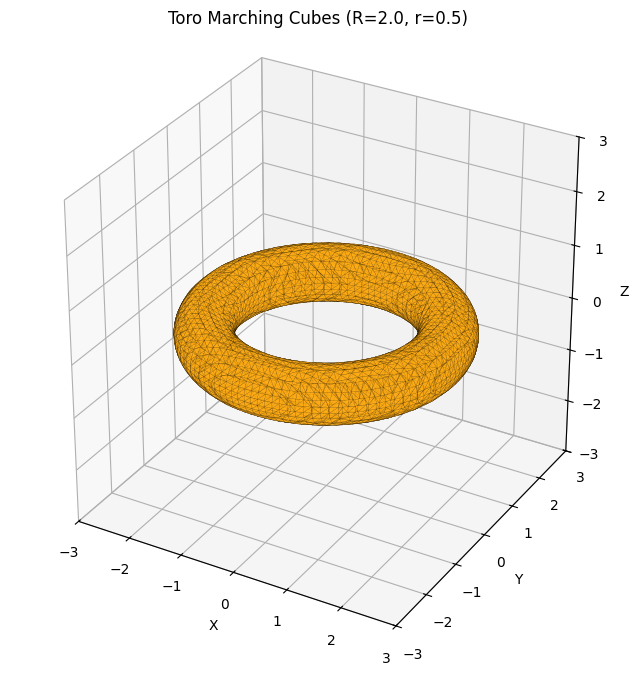

Redimensionando cena (Max atual: 9.87)...


In [ ]:
# ==========================================================
# 2. MONTAGEM DA CENA (GERAÇÃO)
# ==========================================================

print("Gerando objetos...")

# --- 1. Cubo ---
cubo = Cubo(tamanho_aresta=2.0)
dados_cubo = cubo.gerar_marching_cubes(resolucao=32)
v_cubo = dados_cubo['vertices']
f_cubo = dados_cubo['faces']

# --- 2. Toro ---
toro = Toro(R=2.0, r=0.5)
retorno_toro = toro.gerar_marching_cubes(resolucao=50)
# O método do toro retorna 3 valores (v, f, n), pegamos os 2 primeiros
v_toro = retorno_toro[0]
f_toro = retorno_toro[1]

# --- 3. Cano ---
P0, P1, P2, P3 = [0,0,0], [2,5,0], [4,3.5,0], [8,2.5,0]
cano = CanoBezierOco(P0, P1, P2, P3, r_ext=0.6, r_int=0.3, passos=64, fatias=25)
v_cano, f_cano = cano.gerar()

# ==========================================================
# 3. TRANSFORMAÇÕES
# ==========================================================

# Cubo: Escala 1.5x, Rot Y 0, Trans (-5, -3, 0)
v_cubo_final = aplicar_transformacao(v_cubo, escala=(1.5, 1.5, 1.5),
                                     rotacao_eixo='y', rotacao_ang=0, translacao=(-5, -3, 0))

# Toro: Escala 1.2x, Rot X 90, Trans (0, 4, -2)
v_toro_final = aplicar_transformacao(v_toro, escala=(1.2, 1.2, 1.2),
                                     rotacao_eixo='x', rotacao_ang=90, translacao=(0, 4, -2))

# Cano: Escala 0.8x, Rot Z -30, Trans (3, -4, 2)
v_cano_final = aplicar_transformacao(v_cano, escala=(0.8, 0.8, 0.8),
                                     rotacao_eixo='z', rotacao_ang=-30, translacao=(3, -4, -2))

# Normalização Global (para caber no gráfico)
todos_vertices = np.vstack([v_cubo_final, v_toro_final, v_cano_final])
max_val_atual = np.max(np.abs(todos_vertices))

if max_val_atual > 8.0:
    print(f"Redimensionando cena (Max atual: {max_val_atual:.2f})...")
    fator = 8.0 / max_val_atual
    v_cubo_final *= fator
    v_toro_final *= fator
    v_cano_final *= fator

### Visualização

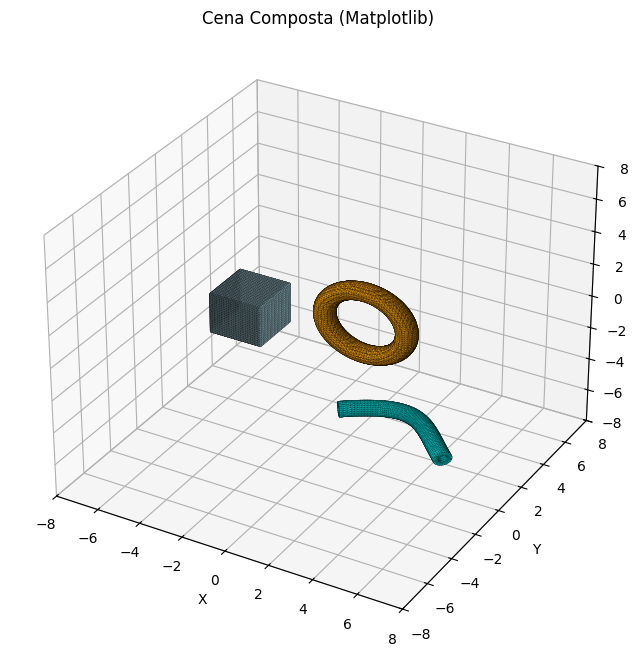

In [ ]:
# ==========================================================
# 4. VISUALIZAÇÃO COM MATPLOTLIB (Estático)
# ==========================================================

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

def plot_mesh(ax, vertices, faces, color, label):
    # linewidth=0.1 e edgecolor='k' criam o efeito de wireframe fino sobre o sólido
    ax.plot_trisurf(vertices[:,0], vertices[:,1], vertices[:,2], triangles=faces,
                    color=color, edgecolor='black', linewidth=0.1, alpha=0.9, label=label)

# Plotando os 3 objetos
# Usando cores distintas para visualização da cena:
# Cubo = Azul, Toro = Laranja, Cano = Ciano
plot_mesh(ax, v_cubo_final, f_cubo, 'lightblue', 'Cubo')
plot_mesh(ax, v_toro_final, f_toro, 'orange', 'Toro')
plot_mesh(ax, v_cano_final, f_cano, 'Cyan', 'Cano Bézier')

# Ajustes de Eixos e Câmera
ax.set_title("Cena Composta (Matplotlib)")
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')

# Ajuste de escala (Aspect Ratio 1:1:1)
# O Matplotlib não tem 'axis equal' 3D nativo perfeito, então forçamos os limites
limits = 8
ax.set_xlim(-limits, limits)
ax.set_ylim(-limits, limits)
ax.set_zlim(-limits, limits)

plt.show()

## 3. Coordenadas da Câmera

### Definição da Câmera e Base

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# ==========================================================
# 1. DEFINIÇÃO DA CÂMERA E BASE (Item A)
# ==========================================================

# Escolha da posição da câmera (Olho)
# Como nossos objetos vão de -8 a 8, vamos posicionar a câmera um pouco longe
camera_pos = np.array([-20.0, 10.0, -20.0])

# Para onde a câmera está olhando (Alvo) -> Origem do mundo
camera_target = np.array([0.0, 0.0, 0.0])

# Vetor "Up" (para cima) do mundo (geralmente Y)
world_up = np.array([0.0, 1.0, 0.0])

def calcular_base_camera(eye, target, up):
    """
    Calcula a base vetorial ortonormal (u, v, n) para a câmera.
    No sistema de mão direita (padrão OpenGL):
    n (z da câmera) = vetor apontando para TRAZ (do alvo para o olho)
    u (x da câmera) = vetor para a DIREITA
    v (y da câmera) = vetor para CIMA (da câmera)
    """
    # 1. Vetor Z da câmera (n): Direção oposta à visão
    z_cam = eye - target
    z_cam = z_cam / np.linalg.norm(z_cam)

    # 2. Vetor X da câmera (u): Produto vetorial entre Up e Z
    x_cam = np.cross(up, z_cam)
    x_cam = x_cam / np.linalg.norm(x_cam)

    # 3. Vetor Y da câmera (v): Produto vetorial entre Z e X
    y_cam = np.cross(z_cam, x_cam)
    # (Já é unitário pois z e x são unitários e ortogonais)

    return x_cam, y_cam, z_cam

# a. Compute a base vetorial (u, v e z)
u, v, n = calcular_base_camera(camera_pos, camera_target, world_up)

print("=== Item A: Base Vetorial da Câmera ===")
print(f"Vetor u (X da câmera/Direita): {u}")
print(f"Vetor v (Y da câmera/Cima):    {v}")
print(f"Vetor n (Z da câmera/Traz):    {n}")
print("=======================================")

=== Item A: Base Vetorial da Câmera ===
Vetor u (X da câmera/Direita): [-0.70710678  0.          0.70710678]
Vetor v (Y da câmera/Cima):    [0.23570226 0.94280904 0.23570226]
Vetor n (Z da câmera/Traz):    [-0.66666667  0.33333333 -0.66666667]


### Transformação de Mundo -> Câmera (Item B)

In [ ]:
# ==========================================================
# 2. TRANSFORMAÇÃO DE MUNDO -> CÂMERA (Item B)
# ==========================================================

def world_to_camera(vertices, eye, u, v, n):
    """
    Transforma vértices do espaço do mundo para o espaço da câmera.
    Matematicamente: P_cam = R * (P_world - Eye)
    Onde R é a matriz construída com as linhas u, v, n.
    """
    # 1. Translação (Mover o mundo para que a câmera fique na origem)
    verts_transladados = vertices - eye

    # 2. Rotação (Projetar nos novos eixos u, v, n via produto escalar)
    # Se verts_transladados é (N, 3) e u é (3,), o dot product projeta.
    x_new = np.dot(verts_transladados, u)
    y_new = np.dot(verts_transladados, v)
    z_new = np.dot(verts_transladados, n)

    return np.stack([x_new, y_new, z_new], axis=1)

# b. Transforme os objetos
v_cubo_cam = world_to_camera(v_cubo_final, camera_pos, u, v, n)
v_toro_cam = world_to_camera(v_toro_final, camera_pos, u, v, n)
v_cano_cam = world_to_camera(v_cano_final, camera_pos, u, v, n)

# d. Transforme também a ORIGEM do mundo (0,0,0) para saber onde ela fica na câmera
origem_mundo_cam = world_to_camera(np.array([[0.0, 0.0, 0.0]]), camera_pos, u, v, n)

### Visualização (Itens C e D)

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


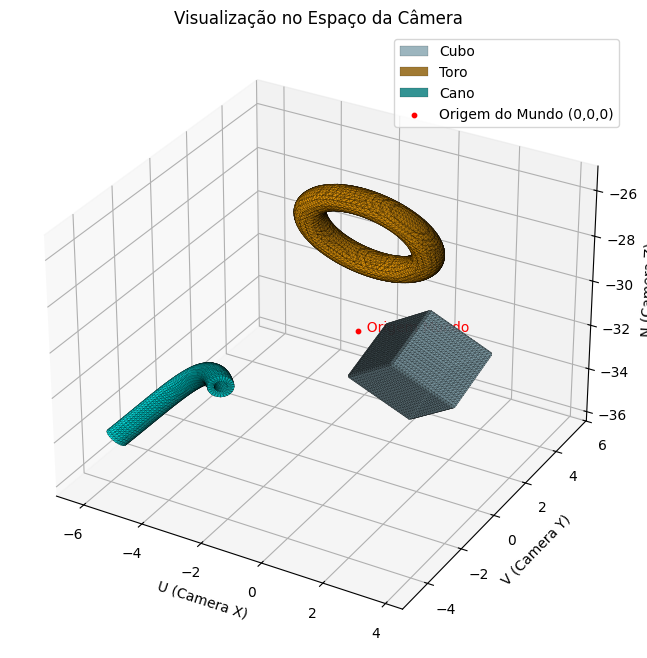

In [ ]:
# ==========================================================
# 3. VISUALIZAÇÃO (Itens C e D)
# ==========================================================

fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

def plot_mesh(ax, vertices, faces, color, label):
    # Usando wireframe preto sobre a cor sólida
    ax.plot_trisurf(vertices[:,0], vertices[:,1], vertices[:,2], triangles=faces,
                    color=color, edgecolor='black', linewidth=0.1, alpha=0.8, label=label)

# c. Mostre os diversos sólidos
plot_mesh(ax, v_cubo_cam, f_cubo, 'lightblue', 'Cubo')
plot_mesh(ax, v_toro_cam, f_toro, 'orange', 'Toro')
plot_mesh(ax, v_cano_cam, f_cano, 'cyan', 'Cano')

# d. Ponto de origem do mundo
origem_x, origem_y, origem_z = origem_mundo_cam[0]
ax.scatter(origem_x, origem_y, origem_z, color='red', s=10, marker='o', label='Origem do Mundo (0,0,0)')
ax.text(origem_x, origem_y, origem_z, "  Origem Mundo", color='red')

ax.set_title("Visualização no Espaço da Câmera")
ax.set_xlabel('U (Camera X)')
ax.set_ylabel('V (Camera Y)')
ax.set_zlabel('N (Camera Z)')

# Em vez de .ptp(), usamos max - min manualmente
all_verts = np.vstack([v_cubo_cam, v_toro_cam, v_cano_cam])

# Calcula a diferença entre max e min para cada eixo (X, Y, Z)
range_x = all_verts[:,0].max() - all_verts[:,0].min()
range_y = all_verts[:,1].max() - all_verts[:,1].min()
range_z = all_verts[:,2].max() - all_verts[:,2].min()

# Pega o maior range para manter a proporção
max_range = np.max([range_x, range_y, range_z]) / 2.0

mid_x = (all_verts[:,0].max() + all_verts[:,0].min()) * 0.5
mid_y = (all_verts[:,1].max() + all_verts[:,1].min()) * 0.5
mid_z = (all_verts[:,2].max() + all_verts[:,2].min()) * 0.5

ax.set_xlim(mid_x - max_range, mid_x + max_range)
ax.set_ylim(mid_y - max_range, mid_y + max_range)
ax.set_zlim(mid_z - max_range, mid_z + max_range)
# =============================

ax.legend()
plt.show()

## 4. Projeção em 2D

### Projeção

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# ==========================================================
# 4. PROJEÇÃO EM PERSPECTIVA (3D -> 2D)
# ==========================================================

# Distância do plano de projeção (semelhante a uma "lente" ou zoom)
# Como a câmera estava em z ~ 30 (distância euclidiana da origem),
# um d=10 ou d=20 dá um campo de visão razoável.
d = 10.0

def projecao_perspectiva(vertices, d):
    """
    Projeta vértices 3D (Espaço da Câmera) para 2D (Plano de Projeção).
    Fórmula: xp = x * (d / -z), yp = y * (d / -z)
    (Usamos -z pois, no espaço da câmera, os objetos estão no eixo Z negativo)
    """
    x = vertices[:, 0]
    y = vertices[:, 1]
    z = vertices[:, 2]

    # Evitar divisão por zero (embora nossos objetos estejam longe, é boa prática)
    # Adicionamos um epsilon ou garantimos que z != 0
    z_safe = np.where(z == 0, 1e-5, z)

    # Fator de perspectiva
    fator = d / (-z_safe)

    xp = x * fator
    yp = y * fator

    # Retorna array (N, 2)
    return np.stack([xp, yp], axis=1)

print("Realizando projeção perspectiva...")

# Aplicar a projeção nos objetos transformados pela câmera
v_cubo_2d = projecao_perspectiva(v_cubo_cam, d)
v_toro_2d = projecao_perspectiva(v_toro_cam, d)
v_cano_2d = projecao_perspectiva(v_cano_cam, d)

# Projetar também a origem para referência
origem_2d = projecao_perspectiva(origem_mundo_cam, d)

Realizando projeção perspectiva...


### Visualização

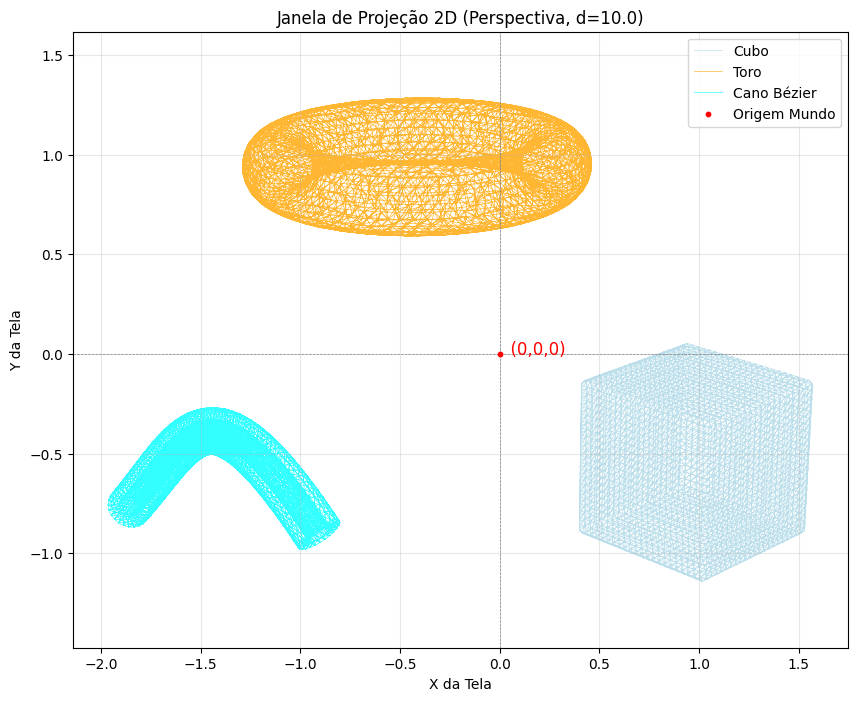

In [ ]:
# ==========================================================
# VISUALIZAÇÃO 2D (Item A)
# ==========================================================

plt.figure(figsize=(10, 8))

# Função auxiliar para desenhar o Wireframe 2D
# Usamos 'triplot' do matplotlib que desenha as arestas dos triângulos em 2D
def plot_2d_object(vertices_2d, faces, color, label):
    plt.triplot(vertices_2d[:, 0], vertices_2d[:, 1], faces,
                color=color, linewidth=0.5, alpha=0.8, label=label)

# Plotando os sólidos
plot_2d_object(v_cubo_2d, f_cubo, 'lightblue', 'Cubo')
plot_2d_object(v_toro_2d, f_toro, 'orange', 'Toro')
plot_2d_object(v_cano_2d, f_cano, 'cyan', 'Cano Bézier')

# Plotando a Origem
plt.scatter(origem_2d[0,0], origem_2d[0,1], color='red', marker='o', s=10, label='Origem Mundo', zorder=10)
plt.text(origem_2d[0,0], origem_2d[0,1], "  (0,0,0)", color='red', fontsize=12)

# Configurações da Janela
plt.title(f"Janela de Projeção 2D (Perspectiva, d={d})")
plt.xlabel("X da Tela")
plt.ylabel("Y da Tela")
plt.axhline(0, color='grey', linewidth=0.5, linestyle='--')
plt.axvline(0, color='grey', linewidth=0.5, linestyle='--')
plt.legend()
plt.axis('equal') # Importante para não distorcer o desenho
plt.grid(True, alpha=0.3)

plt.show()

## 5. Rasterização

### Rasterização

In [ ]:
import numpy as np

# ==========================================================
# 5. RASTERIZAÇÃO COM PRESERVAÇÃO DE ASPECTO
# ==========================================================

class RasterizadorProporcional:
    def __init__(self, largura, altura, min_x, max_x, min_y, max_y):
        self.largura = largura
        self.altura = altura
        self.buffer = [[' ' for _ in range(largura)] for _ in range(altura)]

        # 1. Calcular o tamanho real da cena (em unidades do gráfico)
        range_x = max_x - min_x
        range_y = max_y - min_y

        # Centro da cena (geralmente perto de 0,0)
        center_x = (min_x + max_x) / 2
        center_y = (min_y + max_y) / 2

        # 2. Calcular Fator de Escala (Pixels por Unidade)
        # IMPORTANTE: Caracteres de terminal não são quadrados!
        # Um char geralmente tem 8px de largura e 16px de altura (fator ~0.5 ou ~2.0).
        # Multiplicamos o eixo X por 2.0 para compensar a 'magreza' da letra.
        fator_aspecto_font = 2.0

        # Quantos pixels temos disponíveis?
        pixels_x_disponiveis = largura
        pixels_y_disponiveis = altura

        # Qual escala faz a cena caber na largura? E na altura?
        scale_x = pixels_x_disponiveis / (range_x * fator_aspecto_font)
        scale_y = pixels_y_disponiveis / range_y

        # Pegamos a MENOR escala para garantir que TUDO caiba sem distorcer (Fit)
        self.scale = min(scale_x, scale_y)

        # Guardar parâmetros para conversão
        self.offset_x = center_x
        self.offset_y = center_y
        self.fator_font = fator_aspecto_font
        self.meio_tela_x = largura / 2
        self.meio_tela_y = altura / 2

    def mundo_para_tela(self, x, y):
        """
        Converte coordenada do mundo real para matriz, mantendo proporção.
        Se x=-1.5 e x=1.0 estão longe no gráfico, ficarão longe aqui.
        """
        # Translada para o centro (0,0 relativo)
        dx = x - self.offset_x
        dy = y - self.offset_y

        # Aplica a escala uniforme (com correção da fonte no X)
        px = dx * self.scale * self.fator_font
        py = dy * self.scale

        # Mapeia para o centro da matriz e inverte Y
        coluna = int(self.meio_tela_x + px)
        linha  = int(self.meio_tela_y - py)

        return coluna, linha

    def desenhar_triangulo(self, v1, v2, v3, char='#'):
        # Algoritmo Scanline Padrão
        pts = sorted([v1, v2, v3], key=lambda p: p[1])
        p1, p2, p3 = pts

        def get_x(y, pa, pb):
            if pa[1] == pb[1]: return pa[0] # Linha horizontal
            return pa[0] + (pb[0] - pa[0]) * (y - pa[1]) / (pb[1] - pa[1])

        # Varre do topo até o fim do triângulo
        for y in range(p1[1], p3[1] + 1):
            if y < 0 or y >= self.altura: continue

            # Define limites esquerdo e direito da linha
            if y < p2[1]:
                xa = get_x(y, p1, p2)
                xb = get_x(y, p1, p3)
            else:
                xa = get_x(y, p2, p3)
                xb = get_x(y, p1, p3)

            if xa > xb: xa, xb = xb, xa

            for x in range(int(xa), int(xb) + 1):
                if 0 <= x < self.largura:
                    self.buffer[y][x] = char

    def mostrar(self):
        print(f"\n--- Resolução: {self.largura}x{self.altura} ---")
        bordas = "+" + "-" * self.largura + "+"
        print(bordas)
        for linha in self.buffer:
            print("|" + "".join(linha) + "|")
        print(bordas)

### Execução

In [ ]:
# ==========================================================
# 6. EXECUÇÃO
# ==========================================================

# 1. PEGAR LIMITES GLOBAIS DA SUA PROJEÇÃO EXISTENTE
# (Isso garante que o "espaço vazio" entre o cano e o cubo seja considerado)
todos_vertices = np.vstack([v_cubo_2d, v_toro_2d, v_cano_2d])

# Adicionamos uma margem extra de 5% para não colar na borda do terminal
min_x, max_x = todos_vertices[:,0].min(), todos_vertices[:,0].max()
min_y, max_y = todos_vertices[:,1].min(), todos_vertices[:,1].max()
margem_x = (max_x - min_x) * 0.05
margem_y = (max_y - min_y) * 0.05

# 2. DEFINIR OBJETOS
objetos = [
    (v_cubo_2d, f_cubo, '*'),   # Cubo na direita
    (v_toro_2d, f_toro, ':'),   # Toro em cima
    (v_cano_2d, f_cano, '#')    # Cano na esquerda
]

# 3. RASTERIZAR EM 3 RESOLUÇÕES
resolucoes = [
    (50, 25),    # Baixa
    (100, 50),   # Média
    (140, 70)    # Alta
]

for w, h in resolucoes:
    # Cria o rasterizador passando os limites totais da cena
    rast = RasterizadorProporcional(w, h, min_x - margem_x, max_x + margem_x, min_y - margem_y, max_y + margem_y)

    for verts, faces, char in objetos:
        for face in faces:
            # Pega coord do gráfico
            v1 = verts[face[0]]
            v2 = verts[face[1]]
            v3 = verts[face[2]]

            # Converte para tela
            p1 = rast.mundo_para_tela(v1[0], v1[1])
            p2 = rast.mundo_para_tela(v2[0], v2[1])
            p3 = rast.mundo_para_tela(v3[0], v3[1])

            rast.desenhar_triangulo(p1, p2, p3, char)

    rast.mostrar()


--- Resolução: 50x25 ---
+--------------------------------------------------+
|                                                  |
|                                                  |
|                                                  |
|                                                  |
|                :::::::::::::                     |
|           ::::::::::::::::::::::                 |
|          ::::::::::::::::::::::::                |
|          ::::::::::::::::::::::::                |
|            :::::::::::::::::::::                 |
|                 ::::::::::                       |
|                                                  |
|                                                  |
|                                     *****        |
|                                ****************  |
|      ######                    ****************  |
|    ##########                  ****************  |
|   #############                ****************  |
|  #####    ######  